In [ ]:
!pip install transformers Biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 23.0 MB/s eta 0:00:00


In [ ]:
!pip install matplotlib


In [ ]:
!pip install Biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.3 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import BertModel, BertTokenizer
from Bio import SeqIO
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Model-loading
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
model = BertModel.from_pretrained("Rostlab/prot_bert")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

def get_embeddings(fasta_file):
    sequences = []
    labels = []

    #  Parse FASTA
    for record in SeqIO.parse(fasta_file, "fasta"):
        seq = " ".join(list(str(record.seq)))
        sequences.append(seq)
        labels.append(int(record.description.split("label=")[-1]))

    all_embeddings = []

    #  Extract Features
    with torch.no_grad():
        for seq in sequences:
            ids = tokenizer(seq, return_tensors='pt', padding=True, truncation=True, max_length=512).to(device)
            output = model(**ids)

            # Global Average Pooling: Mean of all amino acid vectors
            embedding = output.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
            all_embeddings.append(embedding)

    return np.array(all_embeddings), np.array(labels)

# FEATURE EXTRACTION
print("Extracting training features...")
X_train, y_train = get_embeddings("/content/train_data.fasta")

print("Extracting testing features...")
X_test, y_test = get_embeddings("/content/test_data.fasta")

print("Done! Feature shapes:", X_train.shape, X_test.shape)

Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting training features...
Extracting testing features...
Done! Feature shapes: (386, 1024) (97, 1024)


In [ ]:
#  Initialize the Random Forest with 'balanced' class weights

clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

#  Train the model
print("Training the Random Forest with balanced weights...")
clf.fit(X_train, y_train)

#  Make predictions
print("Predicting on test data...")
y_pred = clf.predict(X_test)

#  Show the results
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

Training the Random Forest with balanced weights...
Predicting on test data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        61
           1       0.92      0.94      0.93        36

    accuracy                           0.95        97
   macro avg       0.94      0.95      0.95        97
weighted avg       0.95      0.95      0.95        97


--- Confusion Matrix ---
[[58  3]
 [ 2 34]]


In [ ]:
# 1. Initialize the Random Forest with 'balanced' class weights
# This helps if you have more of one type of protein than the other
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Train the model
print("Training the Random Forest with balanced weights...")
clf.fit(X_train, y_train)

# 3. Make predictions
print("Predicting on train data...")
y_pred_train = clf.predict(X_train)

# 4. Show the results
print("\n--- Classification Report ---")
print(classification_report(y_train, y_pred_train))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_train, y_pred_train))

Training the Random Forest with balanced weights...
Predicting on train data...

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      0.99      1.00       144

    accuracy                           1.00       386
   macro avg       1.00      1.00      1.00       386
weighted avg       1.00      1.00      1.00       386


--- Confusion Matrix ---
[[242   0]
 [  1 143]]


In [ ]:
import joblib

# Save the trained Random Forest classifier
joblib.dump(clf, 'protein_classifier_rf.joblib')

# Save the extracted features so you don't have to run ProtBert again
import numpy as np
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

print("Progress Saved! You can find these files in the left folder icon.")

Progress Saved! You can find these files in the left folder icon.


In [ ]:
from sklearn.model_selection import cross_val_score

# Performing 5-Fold Cross-Validation
print("Starting 5-Fold Cross-Validation...")
# We use 'clf' (your Random Forest) and the training embeddings
cv_scores = cross_val_score(clf, X_train, y_train, cv=5)

print("\n--- Cross-Validation Results ---")
print(f"Individual Fold Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Starting 5-Fold Cross-Validation...

--- Cross-Validation Results ---
Individual Fold Scores: [0.97435897 0.96103896 0.97402597 0.96103896 0.94805195]
Mean Accuracy: 0.9637
Standard Deviation: 0.0098


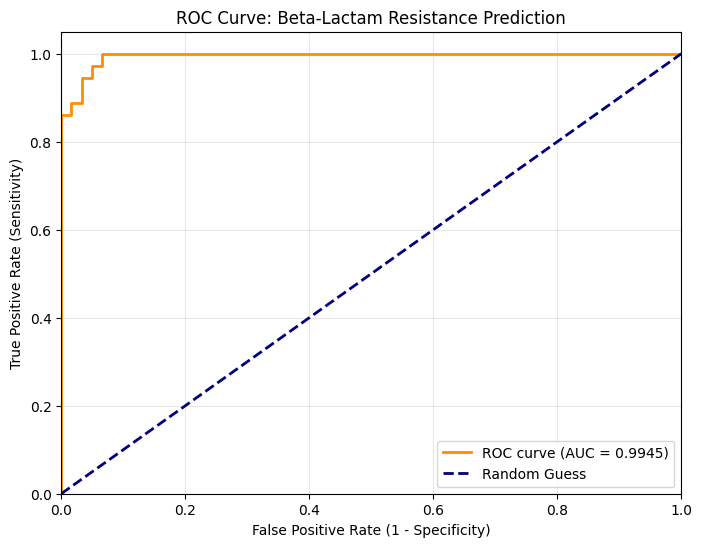

Final Area Under the Curve (AUC): 0.9945


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

#  Get the probability scores for the 'Resistant' class (Class 1)
# We use clf because that is your model's name
y_probs = clf.predict_proba(X_test)[:, 1]

#  Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

#  Create the plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve: Beta-Lactam Resistance Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
# --- ADD THIS LINE TO DOWNLOAD/SAVE ---
plt.savefig('ROC_Curve_Results.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Final Area Under the Curve (AUC): {roc_auc:.4f}")

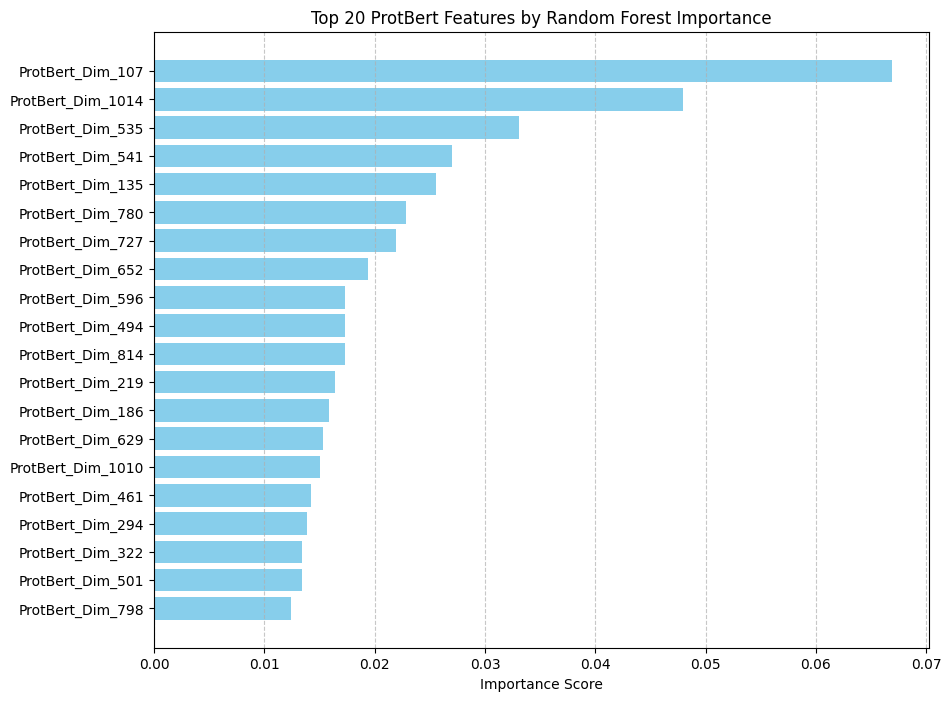

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#  Get feature importances from the trained Random Forest
importances = clf.feature_importances_

#  Sort them in descending order and get the indices
indices = np.argsort(importances)[::-1]

#  Select the top 20 features
top_k = 20
top_indices = indices[:top_k]
top_importances = importances[top_indices]

#  Create feature names
feature_names = [f"ProtBert_Dim_{i}" for i in top_indices]

#  Plotting
plt.figure(figsize=(10, 8))
plt.barh(range(top_k), top_importances, align='center', color='skyblue')
plt.yticks(range(top_k), feature_names)
plt.gca().invert_yaxis()  # Put the most important at the top
plt.xlabel('Importance Score')
plt.title('Top 20 ProtBert Features by Random Forest Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save the plot for your report
plt.savefig('Feature_Importance_Top20.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!pip install Biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.5 MB/s eta 0:00:00


Calculating amino acid frequencies for interpretation...


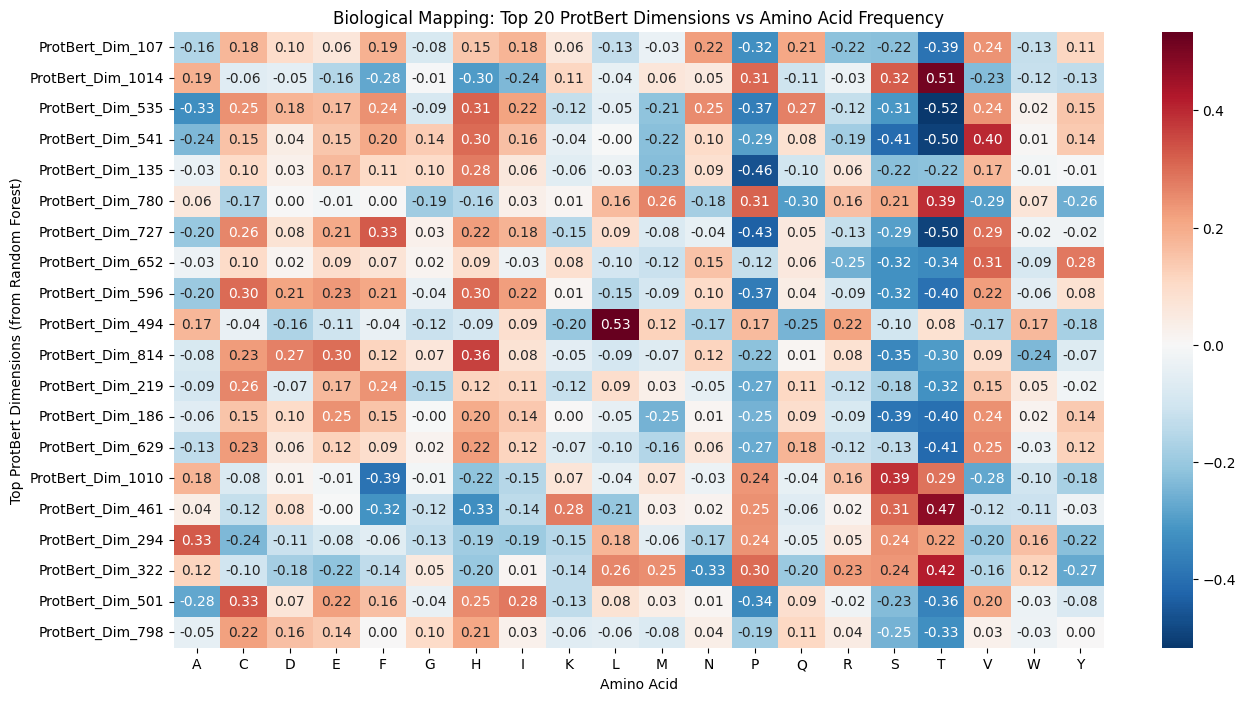

In [ ]:
import pandas as pd
from scipy.stats import spearmanr
import seaborn as sns
from Bio import SeqIO


# 1. We need the raw sequences to calculate Amino Acid frequencies.
# Let's re-extract just the sequences from your test FASTA file.
test_sequences = []
for record in SeqIO.parse("/content/test_data.fasta", "fasta"):
    test_sequences.append(str(record.seq))

# 2. Create a DataFrame from your X_test (the 1024 embeddings)
# This gives us a table where columns are ProtBert_Dim_0, ProtBert_Dim_1, etc.
df_test_embeddings = pd.DataFrame(X_test, columns=[f"ProtBert_Dim_{i}" for i in range(1024)])
df_test_embeddings['Sequence'] = test_sequences

# 3. Calculate Amino Acid Frequencies
amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

def get_aa_freq(seq):
    return {aa: (seq.count(aa) / len(seq)) if len(seq) > 0 else 0 for aa in amino_acids}

print("Calculating amino acid frequencies for interpretation...")
aa_freq_df = df_test_embeddings['Sequence'].apply(get_aa_freq).apply(pd.Series)

# 4. Use the 'feature_names' (Top 20) generated from your RF code
corr_matrix = pd.DataFrame(index=feature_names, columns=amino_acids)

for feature in feature_names:
    dim_values = df_test_embeddings[feature]
    for aa in amino_acids:
        coef, _ = spearmanr(dim_values, aa_freq_df[aa])
        corr_matrix.loc[feature, aa] = coef

# 5. Plot the Correlation Heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Biological Mapping: Top 20 ProtBert Dimensions vs Amino Acid Frequency")
plt.xlabel("Amino Acid")
plt.ylabel("Top ProtBert Dimensions (from Random Forest)")
plt.savefig('Biological_Correlation_Heatmap.png', dpi=300,  bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import torch

def virtual_mutation_test(sequence, pos_to_mutate, new_amino_acid):
    """
    sequence: The original protein string (e.g., 'MAVK...')
    pos_to_mutate: List of indices to change
    new_amino_acid: The AA to insert (e.g., 'T' for Threonine)
    """

    # 1. Create the mutated sequence
    seq_list = list(sequence.replace(" ", "")) # Remove spaces if present
    for pos in pos_to_mutate:
        if pos < len(seq_list):
            seq_list[pos] = new_amino_acid

    mutated_seq = " ".join(seq_list)
    original_seq = " ".join(list(sequence.replace(" ", "")))

    # 2. Extract embeddings for both
    def get_single_embedding(s):
        ids = tokenizer(s, return_tensors='pt', padding=True, truncation=True, max_length=512).to(device)
        with torch.no_grad():
            output = model(**ids)
        return output.last_hidden_state.mean(dim=1).squeeze().cpu().numpy().reshape(1, -1)

    orig_emb = get_single_embedding(original_seq)
    mut_emb = get_single_embedding(mutated_seq)

    # 3. Predict probabilities
    orig_prob = clf.predict_proba(orig_emb)[0][1]
    mut_prob = clf.predict_proba(mut_emb)[0][1]

    print(f"--- Mutation Results ({new_amino_acid}) ---")
    print(f"Original Resistance Probability: {orig_prob:.4f}")
    print(f"Mutated Resistance Probability:  {mut_prob:.4f}")
    print(f"Change: {((mut_prob - orig_prob) / orig_prob * 100):.2f}%")

# --- EXECUTION ---
# Pick a sequence from your test set that is currently labeled 'Non-Resistant'
sample_idx = 12
sample_seq = test_sequences[sample_idx]

# Let's mutate 5 random positions to Threonine (which showed high importance in your heatmap)
positions = list(range(0, 50))
virtual_mutation_test(sample_seq, positions, 'T')

--- Mutation Results (T) ---
Original Resistance Probability: 0.0000
Mutated Resistance Probability:  0.1277
Change: inf%


/tmp/ipykernel_6837/435203373.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Change: {((mut_prob - orig_prob) / orig_prob * 100):.2f}%")
